# Artificial Neural Networks  
 SONAR — Detecting Mines vs. Rocks
 Classify sonar signals as **Mine (M)** or **Rock (R)** using an Artificial Neural Network (ANN).

### Objective
Build a basic ANN model, preprocess the sonar data, tune important hyperparameters, and compare the default model with the tuned model using accuracy, precision, recall, and F1-score.

The dataset contains 208 sonar returns. Each return has 60 numerical signal-energy measurements and one target label:
- M = Mine (metal cylinder)
- R = Rock

## 1. Importing the required libraries

I will use TensorFlow/Keras for building the neural network and scikit-learn for preprocessing and evaluation. Matplotlib and Seaborn are used for simple data visualizations.

In [8]:
pip install tensorflow

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Keeping the results reasonably reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Loading the dataset


In [10]:
data = pd.read_csv("sonardataset.csv")

print("Shape of dataset:", data.shape)
print("\nFirst five rows:")
display(data.head())

print("\nColumn names:")
print(data.columns.tolist())

Shape of dataset: (208, 61)

First five rows:


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R



Column names:
['x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'x_9', 'x_10', 'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19', 'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28', 'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37', 'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46', 'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55', 'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'Y']


### Initial observations

There are 208 observations and 61 columns in total. The first 60 columns are numerical sonar measurements and the last column is the class label. This agrees with the dataset description provided with the assignment.

In [11]:
print("Dataset information:")
data.info()

print("\nClass distribution:")
print(data["Y"].value_counts())

print("\nClass proportions:")
print(data["Y"].value_counts(normalize=True).round(3))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-nu

## 3. Data exploration and preprocessing

Before training the ANN, I checked for missing values, duplicate rows, and unusual values. Since the input variables are numerical, no categorical feature encoding is needed for the 60 predictors. The target is encoded separately as 0 and 1.

The two classes are not exactly equal (111 mines and 97 rocks), but the difference is not very large. I will use a stratified train-test split so that both classes remain represented in similar proportions in the training and test sets.

Total missing values: 0
Number of duplicate rows: 0

Minimum value across numerical features: 0.0
Maximum value across numerical features: 1.0


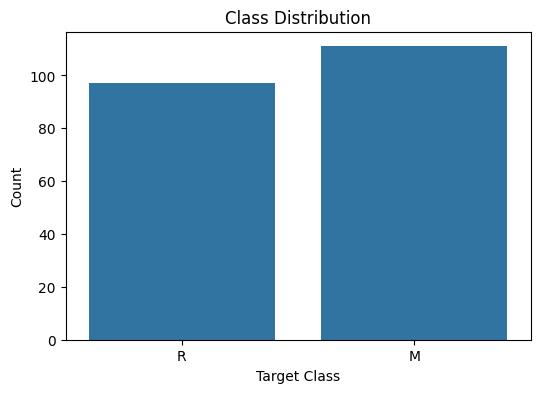

In [12]:
# Missing values
missing_values = data.isnull().sum()
print("Total missing values:", missing_values.sum())

# Duplicate rows
print("Number of duplicate rows:", data.duplicated().sum())

# Check the numerical range
X_raw = data.drop(columns=["Y"])
print("\nMinimum value across numerical features:", X_raw.min().min())
print("Maximum value across numerical features:", X_raw.max().max())

# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="Y")
plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

### Checking the feature distributions

The original measurements are already between 0 and 1 according to the dataset description. Even so, the assignment specifically asks for normalization, and neural networks can benefit from inputs being on a consistent scale. I will use StandardScaler after the train-test split. This also avoids using information from the test set while fitting the scaler.

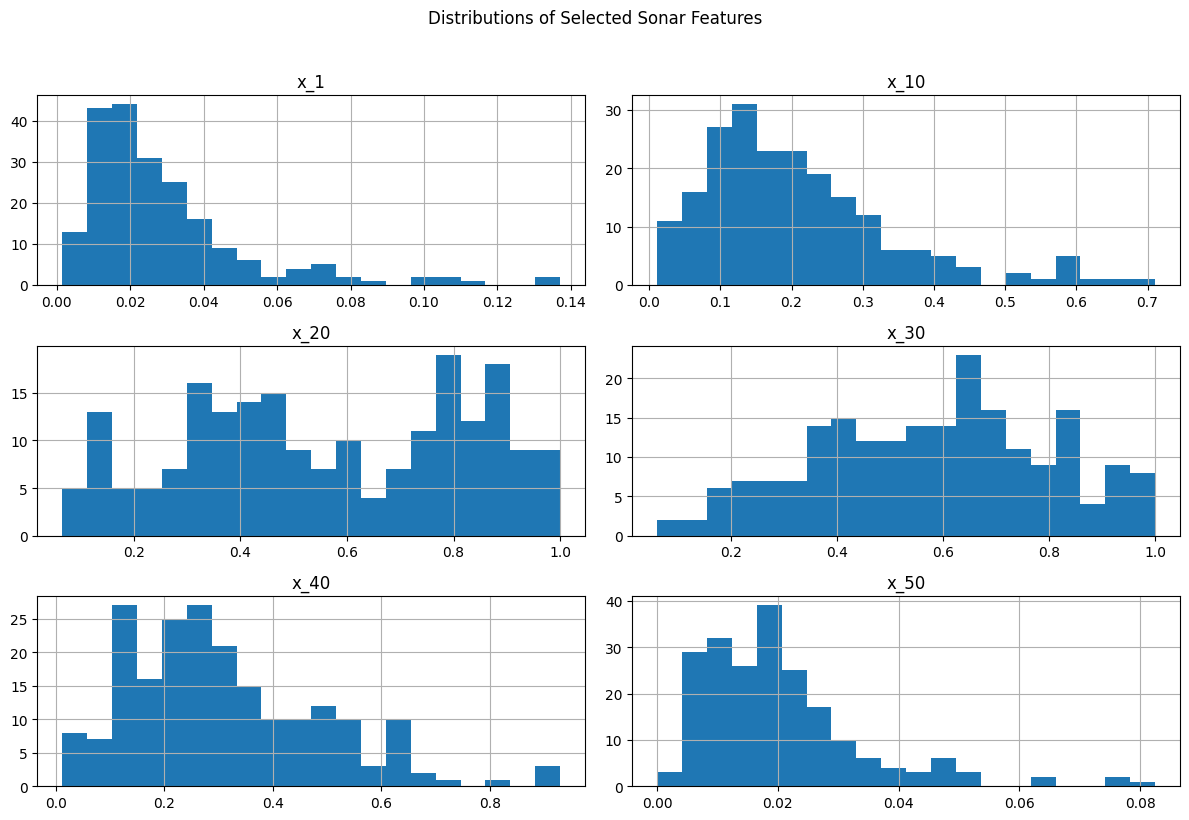

In [13]:
# Distribution of a few selected features
selected_features = ["x_1", "x_10", "x_20", "x_30", "x_40", "x_50"]

data[selected_features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distributions of Selected Sonar Features", y=1.02)
plt.tight_layout()
plt.show()

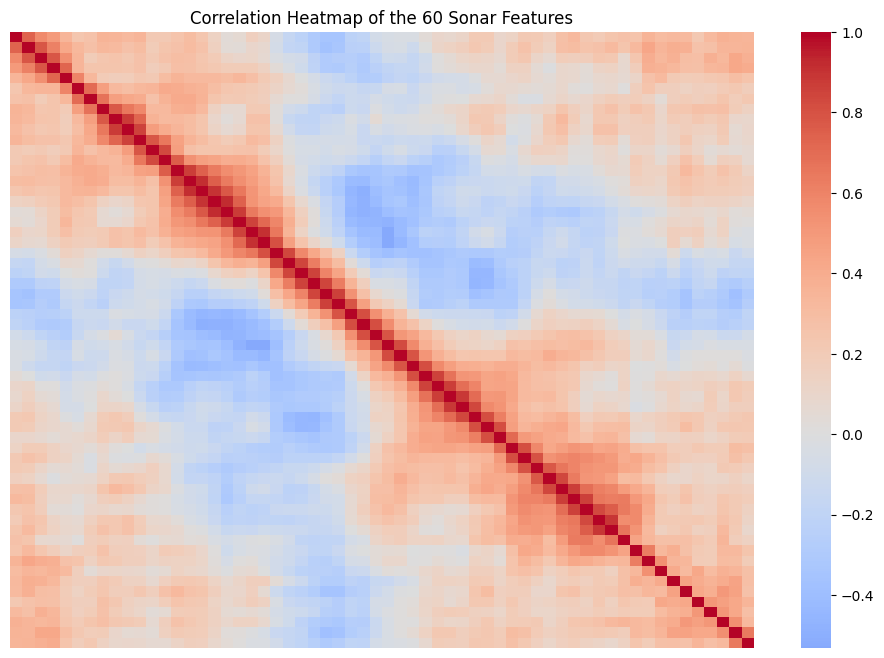

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = X_raw.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title("Correlation Heatmap of the 60 Sonar Features")
plt.show()

## 4. Preparing the input and target

1. Separate the predictors and target.
2. Encode M as 1 and R as 0.
3. Split the data into training and testing sets using an 80:20 split.
4. Standardize the input variables using only the training data.

In [15]:
X = data.drop(columns=["Y"])
y = data["Y"].map({"R": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])
print("Number of input features:", X_train_scaled.shape[1])

print("\nTraining class counts:")
print(y_train.value_counts())

print("\nTesting class counts:")
print(y_test.value_counts())

Training samples: 166
Testing samples: 42
Number of input features: 60

Training class counts:
Y
1    89
0    77
Name: count, dtype: int64

Testing class counts:
Y
1    22
0    20
Name: count, dtype: int64


## 5. Building the basic ANN model

- 60 input features
- One hidden layer with 32 neurons
- ReLU activation in the hidden layer
- One sigmoid output neuron for binary classification
- Adam optimizer
- Binary cross-entropy loss

I will use early stopping so that training can stop when validation loss stops improving.

In [16]:
def build_ann(hidden_layers=(32,), activation="relu", learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))

    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_ann(hidden_layers=(32,), activation="relu", learning_rate=0.001)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training the default ANN

The model is trained using the training data. A validation split is used only from the training data so that the test set remains untouched until final evaluation.

In [17]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("Training completed.")
print("Epochs actually used:", len(history_baseline.history["loss"]))

Training completed.
Epochs actually used: 40


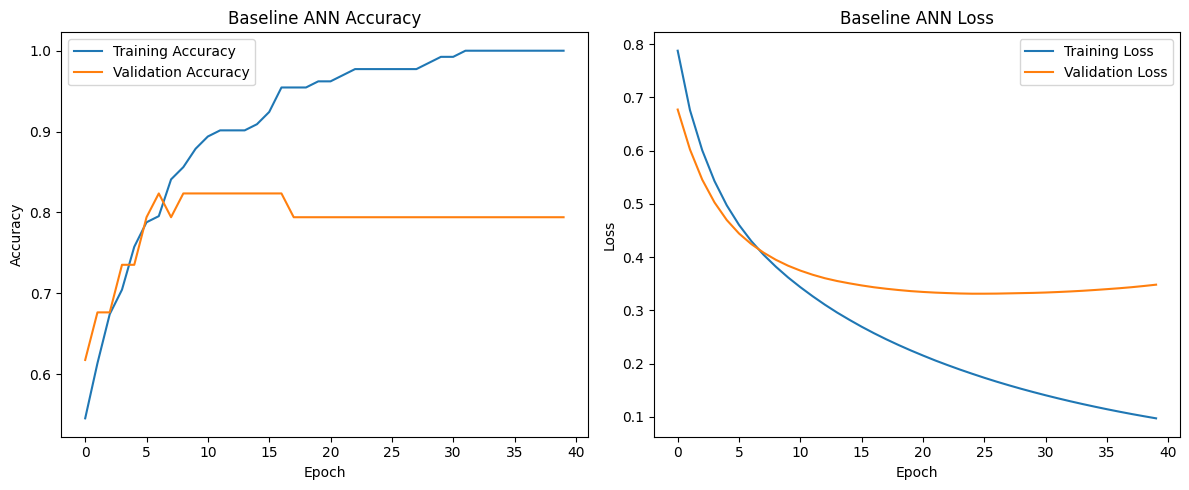

In [18]:
# Plot training and validation performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.title("Baseline ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Evaluating the baseline model

The required evaluation metrics are accuracy, precision, recall, and F1-score. For the binary target, I use **Mine (M = 1)** as the positive class.

In [19]:
def evaluate_model(model, X_eval, y_eval, model_name="Model"):
    probabilities = model.predict(X_eval, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "Recall": recall_score(y_eval, predictions, zero_division=0),
        "F1-score": f1_score(y_eval, predictions, zero_division=0)
    }

    return metrics, predictions

baseline_metrics, baseline_predictions = evaluate_model(
    baseline_model,
    X_test_scaled,
    y_test,
    "Baseline ANN"
)

pd.DataFrame([baseline_metrics])

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline ANN,0.928571,0.913043,0.954545,0.933333


Baseline Classification Report:
              precision    recall  f1-score   support

        Rock       0.95      0.90      0.92        20
        Mine       0.91      0.95      0.93        22

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



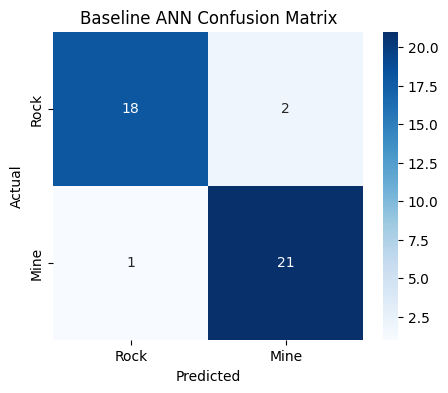

In [20]:
print("Baseline Classification Report:")
print(classification_report(
    y_test,
    baseline_predictions,
    target_names=["Rock", "Mine"],
    zero_division=0
))

cm_baseline = confusion_matrix(y_test, baseline_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rock", "Mine"],
    yticklabels=["Rock", "Mine"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline ANN Confusion Matrix")
plt.show()

In [21]:
tn, fp, fn, tp = cm_baseline.ravel()

manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp) if (tp + fp) else 0
manual_recall = tp / (tp + fn) if (tp + fn) else 0
manual_f1 = (
    2 * manual_precision * manual_recall /
    (manual_precision + manual_recall)
    if (manual_precision + manual_recall) else 0
)

print("TP =", tp, "TN =", tn, "FP =", fp, "FN =", fn)
print("Manually calculated accuracy :", round(manual_accuracy, 4))
print("Manually calculated precision:", round(manual_precision, 4))
print("Manually calculated recall   :", round(manual_recall, 4))
print("Manually calculated F1-score :", round(manual_f1, 4))

TP = 21 TN = 18 FP = 2 FN = 1
Manually calculated accuracy : 0.9286
Manually calculated precision: 0.913
Manually calculated recall   : 0.9545
Manually calculated F1-score : 0.9333


## 9. Hyperparameter tuning

The baseline model is only a starting point. For the tuning stage, I will change:
- Number of hidden layers and neurons
- Activation function
- Learning rate
 I am keeping the search compact so that the models can be compared without making the notebook unnecessarily slow.

In [22]:
# Structured hyperparameter combinations
param_grid = [
    {"hidden_layers": (32,), "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": (64,), "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": (64, 32), "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": (128, 64), "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": (64,), "activation": "tanh", "learning_rate": 0.001},
    {"hidden_layers": (64, 32), "activation": "tanh", "learning_rate": 0.001},
    {"hidden_layers": (64, 32), "activation": "relu", "learning_rate": 0.0005},
    {"hidden_layers": (128, 64), "activation": "relu", "learning_rate": 0.0005},
]

tuning_results = []
tuning_histories = []

for i, params in enumerate(param_grid, start=1):
    print(f"Training configuration {i}/{len(param_grid)}: {params}")

    tf.keras.backend.clear_session()
    np.random.seed(42 + i)
    tf.random.set_seed(42 + i)

    model = build_ann(
        hidden_layers=params["hidden_layers"],
        activation=params["activation"],
        learning_rate=params["learning_rate"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.20,
        epochs=150,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    tuning_results.append({
        "Configuration": i,
        "Hidden Layers": str(params["hidden_layers"]),
        "Activation": params["activation"],
        "Learning Rate": params["learning_rate"],
        "Best Validation Accuracy": best_val_accuracy,
        "Best Validation Loss": best_val_loss,
        "Epochs": len(history.history["loss"])
    })

    tuning_histories.append((params, history))

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values("Best Validation Accuracy", ascending=False)

Training configuration 1/8: {'hidden_layers': (32,), 'activation': 'relu', 'learning_rate': 0.001}
Training configuration 2/8: {'hidden_layers': (64,), 'activation': 'relu', 'learning_rate': 0.001}
Training configuration 3/8: {'hidden_layers': (64, 32), 'activation': 'relu', 'learning_rate': 0.001}
Training configuration 4/8: {'hidden_layers': (128, 64), 'activation': 'relu', 'learning_rate': 0.001}
Training configuration 5/8: {'hidden_layers': (64,), 'activation': 'tanh', 'learning_rate': 0.001}
Training configuration 6/8: {'hidden_layers': (64, 32), 'activation': 'tanh', 'learning_rate': 0.001}
Training configuration 7/8: {'hidden_layers': (64, 32), 'activation': 'relu', 'learning_rate': 0.0005}
Training configuration 8/8: {'hidden_layers': (128, 64), 'activation': 'relu', 'learning_rate': 0.0005}


,Configuration,Hidden Layers,Activation,Learning Rate,Best Validation Accuracy,Best Validation Loss,Epochs
5,6,"(64, 32)",tanh,0.0010,0.911765,0.407896,15
4,5,"(64,)",tanh,0.0010,0.911765,0.400077,15
3,4,"(128, 64)",relu,0.0010,0.882353,0.351108,15
6,7,"(64, 32)",relu,0.0005,0.852941,0.414854,15
7,8,"(128, 64)",relu,0.0005,0.852941,0.332768,15
2,3,"(64, 32)",relu,0.0010,0.823529,0.368440,15
0,1,"(32,)",relu,0.0010,0.794118,0.370120,15
1,2,"(64,)",relu,0.0010,0.794118,0.377695,15


### Selecting the best configuration

The configuration with the highest validation accuracy is selected as the tuned architecture. Validation performance is used here instead of test performance so that the test set is still reserved for the final comparison.

In [23]:
best_index = tuning_df["Best Validation Accuracy"].idxmax()
best_row = tuning_df.loc[best_index]

print("Best configuration:")
display(best_row.to_frame().T)

best_params = param_grid[int(best_row["Configuration"]) - 1]
print("\nSelected hyperparameters:", best_params)

Best configuration:


,Configuration,Hidden Layers,Activation,Learning Rate,Best Validation Accuracy,Best Validation Loss,Epochs
4,5,"(64,)",tanh,0.001,0.911765,0.400077,15



Selected hyperparameters: {'hidden_layers': (64,), 'activation': 'tanh', 'learning_rate': 0.001}


## 10. Training the final tuned ANN

I now rebuild the selected architecture and train it on the training data. The test data is used only after this stage for the final evaluation.

In [24]:
tf.keras.backend.clear_session()
np.random.seed(100)
tf.random.set_seed(100)

tuned_model = build_ann(
    hidden_layers=best_params["hidden_layers"],
    activation=best_params["activation"],
    learning_rate=best_params["learning_rate"]
)

history_tuned = tuned_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("Final tuned model trained.")
print("Epochs actually used:", len(history_tuned.history["loss"]))
tuned_model.summary()

Final tuned model trained.
Epochs actually used: 15


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,909 (46.52 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,940 (31.02 KB)

In [25]:
tuned_metrics, tuned_predictions = evaluate_model(
    tuned_model,
    X_test_scaled,
    y_test,
    "Tuned ANN"
)

comparison = pd.DataFrame([baseline_metrics, tuned_metrics])
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline ANN,0.928571,0.913043,0.954545,0.933333
1,Tuned ANN,0.666667,0.750000,0.545455,0.631579


Tuned Classification Report:
              precision    recall  f1-score   support

        Rock       0.62      0.80      0.70        20
        Mine       0.75      0.55      0.63        22

    accuracy                           0.67        42
   macro avg       0.68      0.67      0.66        42
weighted avg       0.69      0.67      0.66        42



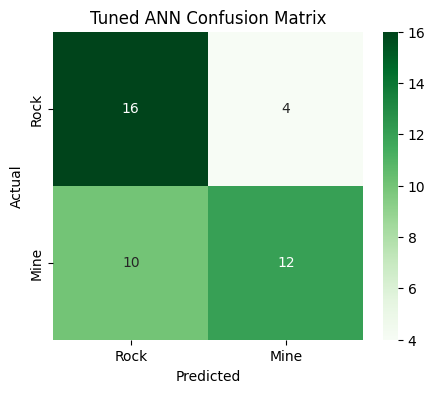

In [26]:
print("Tuned Classification Report:")
print(classification_report(
    y_test,
    tuned_predictions,
    target_names=["Rock", "Mine"],
    zero_division=0
))

cm_tuned = confusion_matrix(y_test, tuned_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rock", "Mine"],
    yticklabels=["Rock", "Mine"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned ANN Confusion Matrix")
plt.show()

## 11. Comparing the baseline and tuned models

The following table makes it easier to see whether hyperparameter tuning improved the model. Since the test set is small, I should avoid treating a small difference as a guaranteed improvement for all unseen sonar signals.

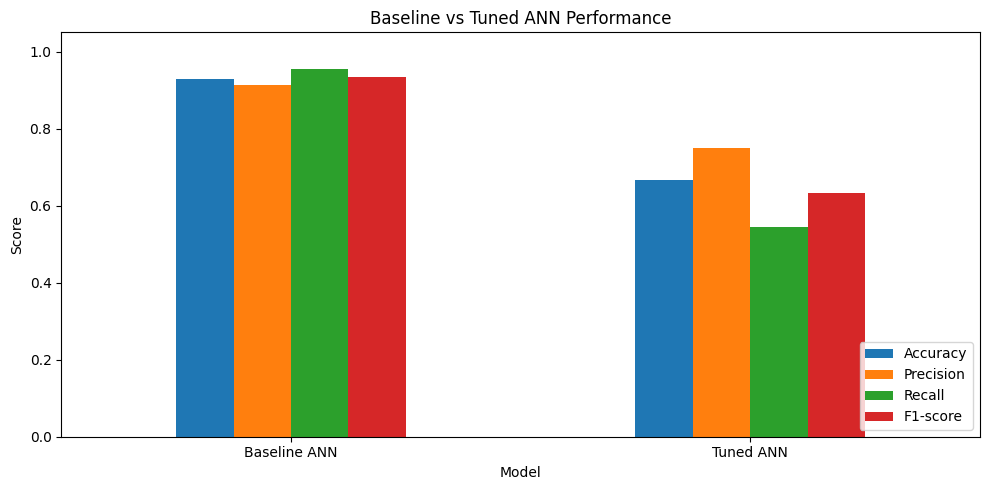

Improvement in test accuracy: -0.2619
Improvement in test F1-score: -0.3018


In [27]:
comparison_plot = comparison.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-score"
]]

comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs Tuned ANN Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Improvement in test accuracy:",
      round(tuned_metrics["Accuracy"] - baseline_metrics["Accuracy"], 4))
print("Improvement in test F1-score:",
      round(tuned_metrics["F1-score"] - baseline_metrics["F1-score"], 4))

## 12. Final observations


1. The dataset contains 208 sonar signals with 60 numerical input features and two target classes.
2. There were no missing values in the supplied CSV file, so no imputation was required.
3. The target classes are slightly imbalanced, so stratified splitting was used to preserve their proportions in the training and test sets.
4. Standardization was applied to the input variables before training the ANN.
5. The baseline model used one hidden layer, while the tuning stage tested different hidden-layer structures, activation functions, and learning rates.
6. The tuned model was selected using validation performance and then evaluated once on the held-out test set.
7. Accuracy, precision, recall, and F1-score were used because all four provide useful information about classification performance.
8. The final comparison should be based on the actual values printed by the notebook after it is run. A higher F1-score is particularly useful when we want a balance between precision and recall.

### Conclusion

The ANN approach is suitable for this binary classification problem because the model can learn nonlinear relationships among the 60 sonar measurements. Hyperparameter tuning gives a systematic way to test whether a deeper network, a different activation function, or a different learning rate improves the classification results. The final model should be judged using the held-out test set rather than only its training accuracy.